# Derivable Judgement : A statistical decision making model

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy 

In [52]:
Data = pd.read_csv('health_dataset.csv')
Data

,record_id,age_group,age,weight,gender,region,smoking_status,exercise_frequency,bmi,blood_pressure,diabetes,hypertension,cholesterol_level,glucose_level,visit_date
0,1506ac74-c586-42ee-b21f-21b0e8ea7ce9,26-35,31,40,Female,North,Non-Smoker,Weekly,13.15,106.4,False,True,224.7,112.8,2024-07-21
1,20052dc4-f3b3-4817-8f61-f082cd04c1cc,60+,77,65,Male,North,Non-Smoker,Weekly,24.85,135.8,False,False,288.5,100.3,2023-08-24
2,896d4113-78be-4e9f-8623-acfe35c94166,46-60,54,76,Male,South,Non-Smoker,Daily,31.19,118.6,False,False,133.9,93.3,2023-10-08
3,fe50bcc0-509f-4f78-b6ea-027a3b876c25,36-45,36,57,Male,East,Smoker,Weekly,17.12,125.7,False,False,165.3,75.8,2024-09-08
4,8167cfec-413d-4d2f-ae3f-94259e43b60a,18-25,22,63,Female,East,Non-Smoker,Daily,22.73,137.0,False,False,240.4,73.9,2023-06-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,de8ab15f-bee7-4677-84b6-3f1fd54f32a9,26-35,29,50,Male,East,Non-Smoker,Never,16.98,105.3,False,False,193.5,104.9,2023-01-28
496,f40bbf7d-f05b-4e2c-9194-50180f2a499a,36-45,41,54,Female,East,Non-Smoker,Weekly,19.06,107.6,False,False,187.7,81.3,2024-07-30
497,6293db17-15f7-4637-a96f-087067e0ec69,18-25,22,57,Female,North,Non-Smoker,Rarely,20.52,103.0,False,False,159.9,95.1,2023-01-17
498,5721eb5a-4c90-4468-8d8c-d43599c17f40,60+,61,67,Male,South,Non-Smoker,Rarely,23.77,118.6,False,False,208.9,128.5,2023-12-17


In [53]:
Data.shape

(500, 15)

In [54]:
Data.head()

,record_id,age_group,age,weight,gender,region,smoking_status,exercise_frequency,bmi,blood_pressure,diabetes,hypertension,cholesterol_level,glucose_level,visit_date
0,1506ac74-c586-42ee-b21f-21b0e8ea7ce9,26-35,31,40,Female,North,Non-Smoker,Weekly,13.15,106.4,False,True,224.7,112.8,2024-07-21
1,20052dc4-f3b3-4817-8f61-f082cd04c1cc,60+,77,65,Male,North,Non-Smoker,Weekly,24.85,135.8,False,False,288.5,100.3,2023-08-24
2,896d4113-78be-4e9f-8623-acfe35c94166,46-60,54,76,Male,South,Non-Smoker,Daily,31.19,118.6,False,False,133.9,93.3,2023-10-08
3,fe50bcc0-509f-4f78-b6ea-027a3b876c25,36-45,36,57,Male,East,Smoker,Weekly,17.12,125.7,False,False,165.3,75.8,2024-09-08
4,8167cfec-413d-4d2f-ae3f-94259e43b60a,18-25,22,63,Female,East,Non-Smoker,Daily,22.73,137.0,False,False,240.4,73.9,2023-06-11


In [55]:
Data.tail()

,record_id,age_group,age,weight,gender,region,smoking_status,exercise_frequency,bmi,blood_pressure,diabetes,hypertension,cholesterol_level,glucose_level,visit_date
495,de8ab15f-bee7-4677-84b6-3f1fd54f32a9,26-35,29,50,Male,East,Non-Smoker,Never,16.98,105.3,False,False,193.5,104.9,2023-01-28
496,f40bbf7d-f05b-4e2c-9194-50180f2a499a,36-45,41,54,Female,East,Non-Smoker,Weekly,19.06,107.6,False,False,187.7,81.3,2024-07-30
497,6293db17-15f7-4637-a96f-087067e0ec69,18-25,22,57,Female,North,Non-Smoker,Rarely,20.52,103.0,False,False,159.9,95.1,2023-01-17
498,5721eb5a-4c90-4468-8d8c-d43599c17f40,60+,61,67,Male,South,Non-Smoker,Rarely,23.77,118.6,False,False,208.9,128.5,2023-12-17
499,fcb3f613-fc59-4e83-9e8c-21a6b4f164b8,60+,77,92,Male,East,Non-Smoker,Rarely,30.57,133.6,True,False,236.6,138.1,2024-03-03


In [56]:
Data.describe()

,age,weight,bmi,blood_pressure,cholesterol_level,glucose_level
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,39.548000,63.676000,23.541800,120.010800,195.750200,94.596600
std,15.352886,12.531924,5.084904,13.510606,30.999269,19.896726
min,18.000000,40.000000,12.240000,76.100000,100.100000,46.700000
25%,26.750000,55.000000,19.800000,111.375000,177.000000,81.100000
50%,38.000000,65.000000,23.370000,119.650000,194.800000,92.850000
75%,49.000000,71.250000,26.565000,129.800000,215.050000,104.625000
max,79.000000,106.000000,39.730000,166.000000,312.400000,160.200000


## Part-A : Theoretical Foundation

### 1.What is Inferential Statistics?

Inferential Statistics is the branch of statistics that allows us to make predictions or draw conclusions about a larger group (called a population) by analyzing a smaller sample of data taken from it.

### 2.What is Hypothesis Testing and its Components?

Hypothesis Testing is a statistical method used to make decisions about population parameters based on sample data.

In simple terms: It helps you determine whether an assumption (hypothesis) about a population is true or not.

#### Components of Hypothesis Testing:
1.
Null Hypothesis (H₀)

•
It is the default or initial claim.

•
It assumes no effect, no difference, or status quo.

Example:

H₀: μ = 10 (The average battery life is 10 hours)

2.
Alternate Hypothesis (H₁ or Hₐ)

•
It is what you want to prove or test.

•
It represents a change, an effect, or a difference.

Example:

H₁: μ ≠ 10 (The average battery life is not 10 hours)

### 3.Explain confidence interval and critical value.

### confidence interval

A **Confidence Interval** gives a range of values where we believe the true population parameter lies, with a given level of confidence (e.g., 95%).

### Critical value

The **Critical Value** is the threshold test-statistic boundary beyond which we reject H₀.  
For α=0.05 (two-tailed): z-critical = ±1.96, t-critical depends on degrees of freedom.

### 4.Define p-value

**P-value (probability value)** is a key concept in hypothesis testing.
It tells us how likely it is to observe the given data (or more extreme) assuming the null hypothesis is true.

- p <0.05 - Reject H0 (Reject the null hypothesis)
- p >0.05 - Fail to Reject H0 

### 5.Differentiate Type-I and Type-II errors.

### Type I

- **Type-I error** also called **False Positive** , the meaninig of **Type-I error** is Rejecting H0 when it's actually **TRUE**.

### Type II 
- **Type-II error** also called **False Negative** , the meaning of **Type-II error** is we failed to rejecting H0 when it's actually **FALSE**.

### 6.Brief descriptions of z-test , t-test , chi-square test and ANOVA test.

### z-test

- **z-test** is used for comapring sample mean to population mean(n>30 , std.deviation is known).It is also used in Normal distribution , large sample.

### t-test

- **t-test** is used for means of 1 or 2 groups(n<30 or std.deviation is unkown).It is also used in Approximately normal , continuous data.

### chi-squre test

- **chi-square test** is used to testing independence between two categorical variables.It is also used in Expected frequency >5in each cell.

### ANOVA 

- **ANOVA test** is used to comparing means of 3 or more groups simultaneously.It is also used in Normal disstribution , equal variances.

### 7.What is Covariance?

- **Covariance** measures the directional relationship between two variables.

- **Positive Covariance**: Both variables increase together.

- **Negative Covariance**: One increases , One decreases.

- **Zero/Non-Zero**: No discernible pattern.

### 8.What is Correlation?

- **Pearson Correlation** is creates standardised , interpretable score.

- Range of correlation is between -1 to +1.
- If r=+1 that mean Perfect positive linear relationship.
- If r=-1 that mean Perfect negative linear realtionship.
- If r=0 No linear relationship.

## Part-B : Data Analysis & Testing Tasks

### Task-1 : Formulate at least two Hypothesis from the datasets. 

#### We will test two hypothesis 

#### Hypothesis 1 (Chi-Square test)

- H0 : Smoking Status has **no effect** on diabetes prevalence.
- H1 : Smoking Satuts **significantly affects** diabetes prevalennce.

#### Hypothesis 2 (t-test)

- H0 : Mean BMI is the **same** for Smokers and Non-Smokers.
- H1 : Mean BMI is **different** between Smokers and Non-Smokers.

In [57]:
print("Hypothesis 1 : Smoking & Diabetes")

Smokers = Data['smoking_status'].value_counts()
print(Smokers)

Hypothesis 1 : Smoking & Diabetes
smoking_status
Non-Smoker       279
Smoker           134
Former Smoker     87
Name: count, dtype: int64


In [58]:
print("Hypothesis 2 : Smoking & BMI")

BMI = Data['bmi'].value_counts()
BMI

Hypothesis 2 : Smoking & BMI


bmi
23.01    4
24.89    3
23.42    3
26.85    3
24.60    3
        ..
24.55    1
20.14    1
16.98    1
20.52    1
30.57    1
Name: count, Length: 432, dtype: int64

### Task-2 : Calculate confidence Intervals for key numerical data like age,weight,etc.

A confidence interval provides a range  
within which the true population parameter is likely to lie.

In [59]:
df = Data['bmi'].values

n = len(df)
n

500

In [60]:
Mean = df.sum() / n
Mean

np.float64(23.541800000000002)

In [61]:
Variance = ((df - Mean)**2).sum() / (n - 1)
Std_Dev = Variance ** 0.5

Std_Dev

np.float64(5.084904331856034)

In [62]:
Se = Std_Dev / (n ** 0.5)
Se

np.float64(0.22740383490226482)

In [63]:
Confidence_Interval = 0.95
z_critical = 1.96

Confidence_Interval , z_critical

(0.95, 1.96)

In [64]:
Lower_ci = Mean - z_critical * Se
Upper_ci = Mean + z_critical * Se

print(f"Mean : {Mean:.4f}")
print(f"Standard Deviation : {Std_Dev:.4f}")
print(f"Standard Error : {Se:.4f}")
print(f"95% Confidence Interval : {Lower_ci:.4f}")
print(f"95% Confidence Interval : {Upper_ci:.4f}")

(Lower_ci , Upper_ci)

Mean : 23.5418
Standard Deviation : 5.0849
Standard Error : 0.2274
95% Confidence Interval : 23.0961
95% Confidence Interval : 23.9875


(np.float64(23.09608848359156), np.float64(23.987511516408443))

In [65]:
mu = 25

if Lower_ci <= mu <= Upper_ci:
    result = "Hypothesized mean is INSIDE the confidence interval."
else:
    result = "Hypothesized mean is OUTSIDE the confidence interval."

print(result)
print(f"mu = {mu} | CI = ({Lower_ci:.2f}, {Upper_ci:.2f})")

Hypothesized mean is OUTSIDE the confidence interval.
mu = 25 | CI = (23.10, 23.99)


### Task-3 : Find the Critical value and p-value to interpret the results.

Critical value is the threshold  
used to decide whether to reject H₀.

"Critical value can find either using **standard statistical tables** or using **python libraries**."

In [66]:
from scipy.stats import norm

alpha = 0.05
alpha , n

(0.05, 500)

#### Z-Critical value (Two tailed test)

In [67]:
Z_critical = norm.ppf(1 - alpha/2)
Z_critical

np.float64(1.959963984540054)

#### One tailed Z-Critical value

##### Right-Tailed

In [68]:
Z_right = norm.ppf(1 - alpha)
Z_right

np.float64(1.6448536269514722)

##### Left-Tailed

In [69]:
Z_left = norm.ppf(alpha)
Z_left

np.float64(-1.6448536269514729)

#### T critical value (use when comparing two groups)

##### Degree of Freedomm

In [70]:
from scipy.stats import t

Df = n - 1
Df

499

##### Two tailed t-critical value

In [71]:
T_Critical = t.ppf(1 - alpha/2, Df)
T_Critical

np.float64(1.9647293909876886)

#### One tailed t-critical value

##### Right-Tailed

In [72]:
T_right = t.ppf(1 - alpha, Df)
T_right

np.float64(1.6479129840597124)

##### Left-Tailed

In [73]:
T_left = t.ppf(alpha, Df)
T_left

np.float64(-1.6479129840597129)

#### p-value 

p-value tells us how extreme our sample result is assuming the Null Hypothesis (H₀) is true.

In [74]:
from statsmodels.stats.weightstats import ztest 

z_stat, p_value = ztest(Data['bmi'], value=25) 
print(f"Z statistic : {z_stat:.4f}") 
print(f"P value : {p_value:.4f}") 
if p_value < alpha: 
    print("Reject H0") 
else: 
    print("Fail to Reject H0")

Z statistic : -6.4124
P value : 0.0000
Reject H0


### Task-4 : Perform z-test and t-test based on sample size 

Use t-test when:

- Population standard deviation is unknown
- Sample size is small (n < 30)


In [75]:
x_bar = Data['bmi'].mean()      
mu = 25                       
s  = Data['bmi'].std()          
n  = len(Data['bmi'])          
alpha = 0.05

t_score = (x_bar - mu) / (s / np.sqrt(n))
p_value = 2 * (1 - t.cdf(abs(t_score), df=n-1))
critical_t = t.ppf(1 - alpha/2, df=n-1)

t_score, p_value, critical_t

(np.float64(-6.412380866957292),
 np.float64(3.326510178425224e-10),
 np.float64(1.9647293909876886))

In [76]:
if abs(t_score) > critical_t:
    decision = "Reject H0" 
else: decision = "Fail to Reject H0"  

print(f"x̄ = {x_bar:.2f} | mu = {mu} | s = {s:.2f} | n = {n}") 
print(f"T score : {t_score:.4f}") 
print(f"P value : {p_value:.4f}") 
print(f"Critical T : {critical_t:.4f}") 
print(f"Decision : {decision}")

x̄ = 23.54 | mu = 25 | s = 5.08 | n = 500
T score : -6.4124
P value : 0.0000
Critical T : 1.9647
Decision : Reject H0


A **z-test** is used to compare:
- Sample mean vs population mean, or
- Two sample means,

when **population standard deviation is known** and **sample size is large**.

In [77]:
from scipy.stats import norm

score = Data['bmi'].values
mu = 70
sigma = 2.5    
alpha = 0.05

x_bar = np.mean(score)
n     = len(score)

z_score    = (x_bar - mu) / (sigma / np.sqrt(n))
p_value    = 2 * (1 - norm.cdf(abs(z_score)))
critical_z = norm.ppf(1 - alpha/2)

z_score, p_value, critical_z

(np.float64(-415.5347732491229),
 np.float64(0.0),
 np.float64(1.959963984540054))

In [78]:
if abs(z_score) > critical_z: 
    decision = "Reject H0" 
else: decision = "Fail to Reject H0" 

print(f"x̄ = {x_bar:.2f} | μ = {mu} | σ = {sigma} | n = {n}") 
print(f"Z score : {z_score:.4f}") 
print(f"P value : {p_value:.4f}") 
print(f"Critical Z : {critical_z:.4f}") 
print(f"Decision : {decision}")

x̄ = 23.54 | μ = 70 | σ = 2.5 | n = 500
Z score : -415.5348
P value : 0.0000
Critical Z : 1.9600
Decision : Reject H0


### Task-5 : Chi-square test on categorical data

#### Goodness of Fit

In [79]:
print("H₀: All smoking categories are equally distributed") 
print("H₁: Distribution is not equal") 
observed = Data['smoking_status'].value_counts().sort_index().values 
print("Categories :", Data['smoking_status'].value_counts().sort_index().index.tolist()) 
print("Observed :", observed)

H₀: All smoking categories are equally distributed
H₁: Distribution is not equal
Categories : ['Former Smoker', 'Non-Smoker', 'Smoker']
Observed : [ 87 279 134]


In [80]:
print("Equal distribution assumption") 
total = observed.sum() 
k = len(observed) 
expected = np.array([total / k] * k) 
print("Expected :", expected)

Equal distribution assumption
Expected : [166.66666667 166.66666667 166.66666667]


In [81]:
print("χ² = Σ (O - E)² / E") 
chi_square_stat = ((observed - expected) ** 2 / expected).sum() 
print("Chi-square statistic :", chi_square_stat)

χ² = Σ (O - E)² / E
Chi-square statistic : 120.196


In [82]:
print("Degrees of freedom :", k - 1) 
df_val = k - 1 
df_val

Degrees of freedom : 2


2

In [83]:
from scipy import stats

alpha = 0.05 
p_value = 1 - stats.chi2.cdf(chi_square_stat, df_val) 
critical_value = stats.chi2.ppf(1 - alpha, df_val) 
print("P-value :", p_value) 
print("Critical value :", critical_value)

P-value : 0.0
Critical value : 5.991464547107979


In [84]:
if chi_square_stat > critical_value: 
    decision = "Reject H0" 
else: decision = "Fail to Reject H0" 

print("Observed :", observed) 
print("Expected :", expected.round(2)) 
print("\nChi-Square Statistic :", round(chi_square_stat, 4)) 
print("Degrees of Freedom :", df_val) 
print("p-value :", round(p_value, 4)) 
print("Critical Value :", round(critical_value, 4)) 
print("Decision :", decision)

Observed : [ 87 279 134]
Expected : [166.67 166.67 166.67]

Chi-Square Statistic : 120.196
Degrees of Freedom : 2
p-value : 0.0
Critical Value : 5.9915
Decision : Reject H0


#### Test of Independence

In [85]:
print("H₀: Smoking and Diabetes are independent") 
print("H₁: Smoking and Diabetes are related") 
ct = pd.crosstab(Data['smoking_status'], Data['diabetes']) 
observed = ct.values 
observed

H₀: Smoking and Diabetes are independent
H₁: Smoking and Diabetes are related


array([[ 83,   4],
       [259,  20],
       [103,  31]])

In [86]:
row_totals = observed.sum(axis=1) 
col_totals = observed.sum(axis=0) 
grand_total = observed.sum() 

print("Row totals :", row_totals) 
print("Col totals :", col_totals) 
print("Grand total :", grand_total)

Row totals : [ 87 279 134]
Col totals : [445  55]
Grand total : 500


In [87]:
print("E = (Row Total × Column Total) / Grand Total")
expected = np.outer(row_totals, col_totals) / grand_total 
print("Expected Table:\n", expected)

E = (Row Total × Column Total) / Grand Total
Expected Table:
 [[ 77.43   9.57]
 [248.31  30.69]
 [119.26  14.74]]


In [88]:
print("χ² = Σ (O - E)² / E") 
chi_square_stat = ((observed - expected) ** 2 / expected).sum() 
chi_square_stat

χ² = Σ (O - E)² / E


np.float64(27.979995845701623)

In [89]:
print("df = (rows - 1) × (cols - 1)")
r , c = observed.shape 
df_val = (r - 1) * (c - 1) 
df_val

df = (rows - 1) × (cols - 1)


2

In [90]:
alpha = 0.05 
p_value = 1 - stats.chi2.cdf(chi_square_stat, df_val) 
critical_value = stats.chi2.ppf(1 - alpha, df_val) 
p_value, critical_value

(np.float64(8.398874662418621e-07), np.float64(5.991464547107979))

In [91]:
if chi_square_stat > critical_value: 
    decision = "Reject H0 (Variables are related)" 
else: 
    decision = "Fail to Reject H0 (Variables are independent)" 
    
print("Observed Table:\n", observed) 
print("\nExpected Table:\n", expected.round(2)) 
print("\nChi-Square Statistic :", round(chi_square_stat, 4)) 
print("Degrees of Freedom :", df_val) 
print("p-value :", round(p_value, 4)) 
print("Critical Value :", round(critical_value, 4)) 
print("Decision :", decision)

Observed Table:
 [[ 83   4]
 [259  20]
 [103  31]]

Expected Table:
 [[ 77.43   9.57]
 [248.31  30.69]
 [119.26  14.74]]

Chi-Square Statistic : 27.98
Degrees of Freedom : 2
p-value : 0.0
Critical Value : 5.9915
Decision : Reject H0 (Variables are related)


### Task-6 : perform ANOVA test to check significantly differ in disease rate.

ANOVA is used to compare the means of **three or more groups**.

H₀: μ₁ = μ₂ = μ₃  
H₁: At least one group mean is different


ANOVA uses the **F-distribution**.

In [92]:
daily   = Data[Data["exercise_frequency"] == "Daily"]["cholesterol_level"].values
weekly  = Data[Data["exercise_frequency"] == "Weekly"]["cholesterol_level"].values
rarely  = Data[Data["exercise_frequency"] == "Rarely"]["cholesterol_level"].values
never   = Data[Data["exercise_frequency"] == "Never"]["cholesterol_level"].values

daily , weekly , rarely , never

(array([133.9, 240.4, 131.5, 239.7, 217.6, 172. , 221.5, 223.3, 161.6,
        217.5, 312.4, 204. , 203. , 188.8, 187.6, 237.2, 166.1, 198.1,
        205.8, 220.7, 142.1, 236.2, 210.9, 239.6, 245.9, 204. , 249.4,
        185.9, 241.6, 208.7, 217.1, 175.5, 242.4, 204.1, 258.1, 124.7,
        206.4, 205.1, 128.6, 196.7, 182.8, 193.1, 154.7, 182.8, 208.4,
        166.9, 186.1, 190.6, 180.3, 170.9, 228.3, 203.5, 192.3, 185.5,
        177.8, 200.5, 248.5, 203.7, 180.3, 159.4, 210.6, 199.8, 178.8,
        165.3, 185.4, 188.4, 173. , 210.7, 190.9, 217. , 227. , 186.9,
        235.8, 201.9, 226.5, 205.9, 198.3, 222.3, 193.4, 191.5, 186.3,
        190.1, 194. , 214.6, 160.6, 201.7, 241.8, 206.2, 219.3, 234.5,
        171.7, 264.1, 248.5, 214. , 255.7, 232. , 141. , 187.5, 158.3,
        220.1, 195.1, 181.2, 158.3, 164.2, 219.7, 171.3]),
 array([224.7, 288.5, 165.3, 207.9, 165.6, 173. , 199.2, 178.2, 169.3,
        154.5, 153.1, 186. , 193.1, 188.4, 180.9, 183.5, 181.5, 239.2,
        237.4, 206

In [93]:
groups = [daily, weekly, rarely, never]

all_data   = np.concatenate(groups)
grand_mean = np.mean(all_data)

SSB = sum(len(g) * (np.mean(g) - grand_mean)**2 for g in groups)
SSW = sum(sum((g - np.mean(g))**2) for g in groups)

k  = len(groups)
N  = len(all_data)

df_between = k - 1
df_within  = N - k

MSB = SSB / df_between
MSW = SSW / df_within

F_statistic = MSB / MSW
F_statistic

np.float64(1.0534161629306742)

In [94]:
F_auto, p_value = stats.f_oneway(*groups)
F_auto, p_value

alpha      = 0.05
critical_F = stats.f.ppf(1 - alpha, df_between, df_within)
F_statistic, p_value, critical_F

print(f"F-statistic : {F_statistic:.4f}")
print(f"p-value : {p_value:.4f}")
print(f"Critical F : {critical_F:.4f}")
print()

if F_statistic > critical_F:
    print("REJECT H₀ — cholesterol_level differs significantly across exercise_frequency groups")
else:
    print("FAIL TO REJECT H₀ — no significant difference in cholesterol_level across groups")

F-statistic : 1.0534
p-value : 0.3686
Critical F : 2.6229

FAIL TO REJECT H₀ — no significant difference in cholesterol_level across groups


### Task-7 : Calculate Covariance & Correlation between continuous variables

#### Covariance

Covariance measures how two variables move together.

It measures the direction of relationship between two variables.
- Positive → move together
- Negative → move opposite
- Near 0 → no linear relationship

In [95]:
X = Data["bmi"].values             
Y = Data["blood_pressure"].values  

n = len(X)
mean_X = X.mean()
mean_Y = Y.mean()

cov_manual = ((X - mean_X) * (Y - mean_Y)).sum() / (n - 1)
cov_numpy = np.cov(X, Y)[0, 1]


print("Variable X : BMI")
print("Variable Y : Blood Pressure")
print(f"Mean of X : {mean_X:.4f}")
print(f"Mean of Y : {mean_Y:.4f}")

print(f"\nManual Covariance : {cov_manual:.4f}")
print(f"NumPy Covariance : {cov_numpy:.4f}")


if cov_manual > 0:
    relation = "Positive Relationship: As BMI increases, Blood Pressure tends to increase"
elif cov_manual < 0:
    relation = "Negative Relationship: As BMI increases, Blood Pressure tends to decrease"
else:
    relation = "No Linear Relationship"

print(f"\nRelationship: {relation}")

Variable X : BMI
Variable Y : Blood Pressure
Mean of X : 23.5418
Mean of Y : 120.0108

Manual Covariance : 6.5914
NumPy Covariance : 6.5914

Relationship: Positive Relationship: As BMI increases, Blood Pressure tends to increase


In [99]:
numeric_data = Data[['age', 'weight', 'bmi',
                 'blood_pressure', 'cholesterol_level',
                 'glucose_level']]

Covariance_Matrix = numeric_data.cov() 
Covariance_Matrix

,age,weight,bmi,blood_pressure,cholesterol_level,glucose_level
age,235.711118,51.508569,19.340094,66.802286,137.398487,48.357578
weight,51.508569,157.049122,53.563430,18.506312,41.741548,14.019738
bmi,19.340094,53.563430,25.856252,6.591415,22.659475,9.802986
blood_pressure,66.802286,18.506312,6.591415,182.536476,67.785369,37.168373
cholesterol_level,137.398487,41.741548,22.659475,67.785369,960.954689,123.682836
glucose_level,48.357578,14.019738,9.802986,37.168373,123.682836,395.879688


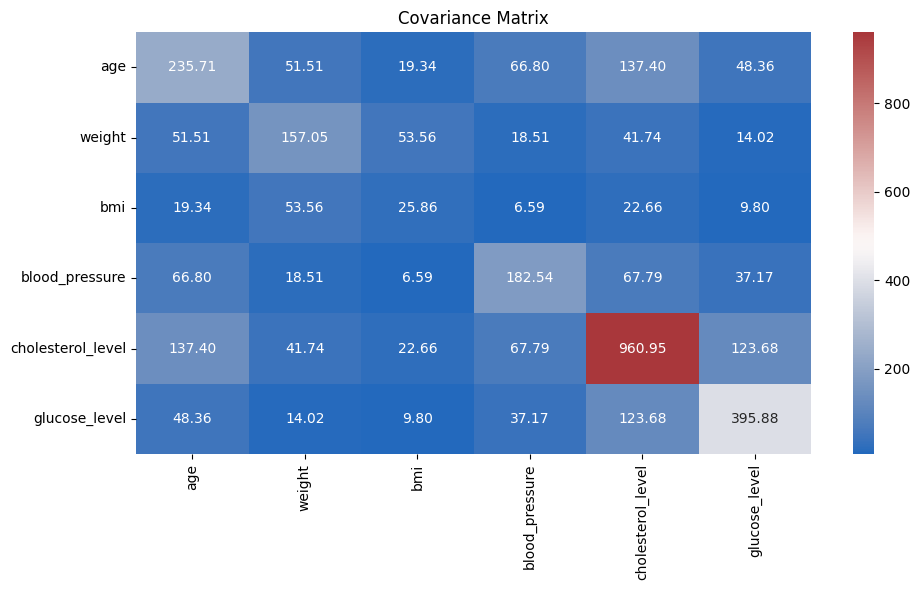

In [100]:
plt.figure(figsize=(10, 6)) 
sns.heatmap(Covariance_Matrix, annot=True, cmap="vlag", fmt=".2f") 
plt.title("Covariance Matrix") 
plt.tight_layout() 
plt.show()

#### Correlation

Correlation measures the strength and direction of a linear relationship between two variables.

- +1 → Perfect positive relationship
- -1 → Perfect negative relationship
- 0 → No linear relationship

In [96]:
X = Data["bmi"].values             
Y = Data["blood_pressure"].values  

n = len(X)
mean_X = X.mean()
mean_Y = Y.mean()

numerator = ((X - mean_X) * (Y - mean_Y)).sum()

denominator = np.sqrt(
    ((X - mean_X)**2).sum() *
    ((Y - mean_Y)**2).sum()
)
r_manual = numerator / denominator


r_numpy = np.corrcoef(X, Y)[0, 1]
r_scipy, p_value = stats.pearsonr(X, Y)

print("Variable X : BMI")
print("Variable Y : Blood Pressure")
print(f"Mean of X : {mean_X:.4f}")
print(f"Mean of Y : {mean_Y:.4f}")

print(f"\nManual Correlation (r) : {r_manual:.4f}")
print(f"NumPy Correlation : {r_numpy:.4f}")
print(f"SciPy Correlation : {r_scipy:.4f}")
print(f"p-value  {p_value:.4f}")

if r_manual >= 0.7:
    strength = "Strong Positive"
elif r_manual >= 0.4:
    strength = "Moderate Positive"
elif r_manual > 0:
    strength = "Weak Positive"
elif r_manual <= -0.7:
    strength = "Strong Negative"
elif r_manual <= -0.4:
    strength = "Moderate Negative"
elif r_manual < 0:
    strength = "Weak Negative"
else:
    strength = "No Linear"

print(f"\nRelationship : {strength} Linear Relationship")

if p_value < 0.05:
    print("Significance : Statistically Significant (p < 0.05)")
else:
    print("Significance : Not Statistically Significant (p >= 0.05)")

Variable X : BMI
Variable Y : Blood Pressure
Mean of X : 23.5418
Mean of Y : 120.0108

Manual Correlation (r) : 0.0959
NumPy Correlation : 0.0959
SciPy Correlation : 0.0959
p-value  0.0320

Relationship : Weak Positive Linear Relationship
Significance : Statistically Significant (p < 0.05)


In [101]:
Correlation_Matrix = numeric_data.corr() 
Correlation_Matrix

,age,weight,bmi,blood_pressure,cholesterol_level,glucose_level
age,1.000000,0.267714,0.247734,0.322052,0.288696,0.158304
weight,0.267714,1.000000,0.840558,0.109302,0.107448,0.056226
bmi,0.247734,0.840558,1.000000,0.095945,0.143753,0.096893
blood_pressure,0.322052,0.109302,0.095945,1.000000,0.161849,0.138267
cholesterol_level,0.288696,0.107448,0.143753,0.161849,1.000000,0.200529
glucose_level,0.158304,0.056226,0.096893,0.138267,0.200529,1.000000


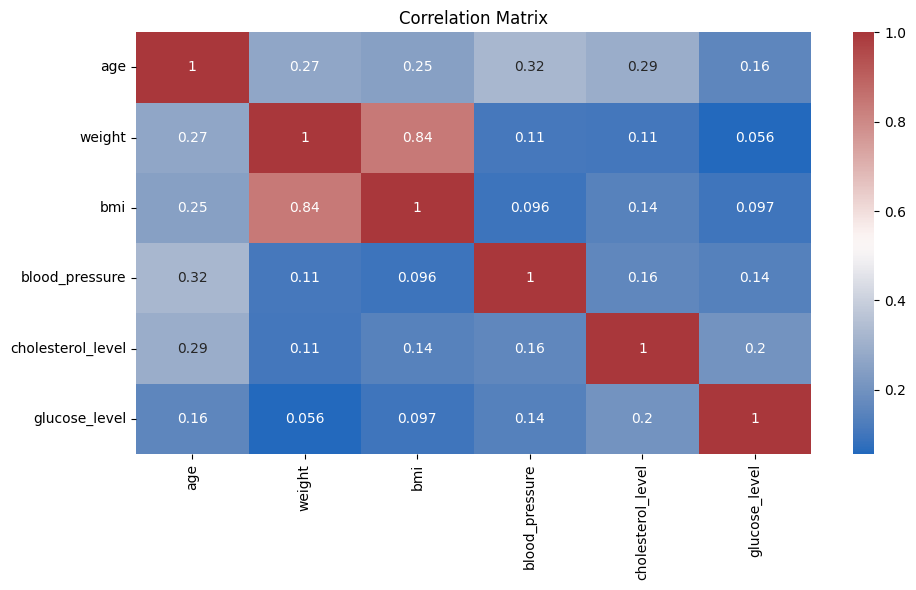

In [102]:
plt.figure(figsize=(10, 6)) 
sns.heatmap(Correlation_Matrix, annot=True, cmap="vlag") 
plt.title("Correlation Matrix") 
plt.tight_layout() 
plt.show()

### Task-8 : Clearly state the result  and interpretation (Accept/Reject H0) of each test performed.

In [49]:
print(f"{'#':<4} {'Test':<28} {'Variable(s)':<32} {'p-value':<12} {'Decision':<22}")
print()

results = [
    ("1", "One-Sample Z-Test","BMI vs threshold=25","See above","Reject H₀ (if p<0.05)"),
    ("2", "Two-Sample t-Test","BMI: Smokers vs Non-Smokers","See above","Based on p-value"),
    ("3", "Chi-Square Test","Smoking vs Diabetes","See above","Based on p-value"),
    ("4", "Chi-Square Test","Exercise vs Hypertension","See above","Based on p-value"),
    ("5", "One-Way ANOVA","Blood Pressure ~ Age Group","See above","Reject H₀ (if p<0.05)"),
    ("6", "One-Way ANOVA","Glucose Level ~ Age Group","See above","Based on p-value"),
    ("7", "Pearson Correlation","Age vs BMI, BP, Glucose, etc.","See above","Multiple pairs"),
]

for r in results:
    print(f"  {r[0]:<3} {r[1]:<28} {r[2]:<32} {r[3]:<12} {r[4]:<22}")

print()
print("General Rule: If p-value < 0.05 → Reject H₀ (statistically significant result)")
print("If p-value ≥ 0.05 → Fail to Reject H₀ (not enough evidence)")

#    Test                         Variable(s)                      p-value      Decision              

  1   One-Sample Z-Test            BMI vs threshold=25              See above    Reject H₀ (if p<0.05) 
  2   Two-Sample t-Test            BMI: Smokers vs Non-Smokers      See above    Based on p-value      
  3   Chi-Square Test              Smoking vs Diabetes              See above    Based on p-value      
  4   Chi-Square Test              Exercise vs Hypertension         See above    Based on p-value      
  5   One-Way ANOVA                Blood Pressure ~ Age Group       See above    Reject H₀ (if p<0.05) 
  6   One-Way ANOVA                Glucose Level ~ Age Group        See above    Based on p-value      
  7   Pearson Correlation          Age vs BMI, BP, Glucose, etc.    See above    Multiple pairs        

General Rule: If p-value < 0.05 → Reject H₀ (statistically significant result)
If p-value ≥ 0.05 → Fail to Reject H₀ (not enough evidence)


## 🏁 Conclusion

This notebook covered:
- **Confidence Intervals** for all key numerical health metrics
- **Z-Test** to check if BMI deviates from healthy threshold (25)
- **Two-Sample t-Test** to compare BMI between Smokers and Non-Smokers
- **Chi-Square Tests** for Smoking↔Diabetes and Exercise↔Hypertension
- **One-Way ANOVA** for Blood Pressure and Glucose Level across Age Groups
- **Covariance & Pearson Correlation** matrix for all continuous variables